# Pre trained infer

加载前需要进行更改
  1. 下载ntv3_base_model，并将modeling_ntv3_pretrained.py，tokenization_ntv3.py，configuration_ntv3_pretrained.py复制到对应文件夹中
  2. 更改tokenizer_config.json中"auto_map"为"AutoTokenizer": ["tokenization_ntv3.NTv3Tokenizer", null]
  3. 更改config.json "auto_map"为
     {
        "AutoConfig": "configuration_ntv3_pretrained.Ntv3PreTrainedConfig",
        "AutoModelForMaskedLM": "modeling_ntv3_pretrained.NTv3PreTrained"
      }
  5. 更改modeling_ntv3_pretrained.py中import类，仅保留from .configuration_ntv3_pretrained import Ntv3PreTrainedConfig

In [1]:
from Bio import SeqIO
from transformers import AutoConfig, AutoModelForMaskedLM, AutoTokenizer
import torch

/root/peaks2/.pixi/envs/training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# init
model_path = "./weight/NTV3_8M_pre"
tokenizer = AutoTokenizer.from_pretrained(model_path, trust_remote_code=True)
config = AutoConfig.from_pretrained(model_path, trust_remote_code=True)
model = AutoModelForMaskedLM.from_pretrained(model_path, config=config, trust_remote_code=True)

model.to(device)

NTv3PreTrained(
  (core): Core(
    (embed_layer): Embedding(11, 16)
    (stem): Stem(
      (conv): Conv1d(16, 256, kernel_size=(15,), stride=(1,), padding=same)
    )
    (conv_tower_blocks): ModuleList(
      (0-6): 7 x ConvTowerBlock(
        (conv): ConvBlock(
          (conv): Conv1d(256, 256, kernel_size=(5,), stride=(1,), padding=same)
          (layer_norm): LayerNormFP32((np.int64(256),), eps=1e-05, elementwise_affine=True)
        )
        (res_conv): ResidualConvBlock(
          (conv_block): ConvBlock(
            (conv): Conv1d(256, 256, kernel_size=(1,), stride=(1,), padding=same)
            (layer_norm): LayerNormFP32((np.int64(256),), eps=1e-05, elementwise_affine=True)
          )
        )
        (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
      )
    )
    (transformer_blocks): ModuleList(
      (0-1): 2 x SelfAttentionBlock(
        (self_attention_layer_norm): LayerNormFP32((256,), eps=1e-05, elementwise_affine=True)
        (final_layer_

In [21]:
genomeseq_dict = SeqIO.to_dict(SeqIO.parse("./data/A157.chr.fa", "fasta"))

In [25]:
seq = genomeseq_dict['A157_chr01'].seq[182095 - 12800:182095 + 12800]

In [37]:
tokens = tokenizer(str(seq), padding="max_length", truncation=True, max_length=25600, return_tensors="pt",)
tokens = tokens["input_ids"][0]

tensor([7, 6, 7,  ..., 9, 8, 6], device='cuda:0')

In [47]:
embeddings = model(input_ids=tokens.to(device).unsqueeze(0), output_hidden_states=True)

In [54]:
embeddings.hidden_states[-1].shape

torch.Size([1, 25600, 256])

# Data

In [2]:
from model.dataset import GenomeBigWigDataset
from model.utils import transform_fn, load_Data
import pandas as pd
import os
import pathlib
import pyfaidx
from transformers import AutoConfig, AutoModelForMaskedLM, AutoTokenizer
import torch
from torch.utils.data import DataLoader
import toml
import time

def load_config(config_path: str):
    with open(config_path, "r") as f:
        config = toml.load(f)
    return config

tokenizer = AutoTokenizer.from_pretrained("/root/peaks2/NTv3/weight/NTV3_8M_pre")

config = load_config("config/fineturn_my.toml")
print(config)

faidx = pyfaidx.Fasta(config["fasta_path"])
gene_bed = os.path.join(config["training_data_dir"], config["gene_bed"])
gene_bed = pd.read_csv(gene_bed, sep="\t", header=None, names=["chrom", "start", "end", "id", "type"])
gene_bed = load_Data(gene_bed, faidx, config["TSS_up"], config["TSS_down"])
faidx.close()

train_dataset = GenomeBigWigDataset(
    fasta_path="/vepfs-C/vepfs_public/daijc/lncRNA/training_data/A157.fa",
    bigwig_path_list=[os.path.join(config["training_data_dir"], f) for f in config["bigwig_files"]],
    chrom_regions = gene_bed,
    sequence_length=config["sequence_length"],
    tokenizer=tokenizer,
    transform_fn = transform_fn,
    keep_target_center_fraction=0.5,
    num_samples=len(gene_bed)
)

# for batch in DataLoader(train_dataset, batch_size=16, num_workers=4, prefetch_factor=2):
#     # print(batch)
#     i += 1
#     print(batch['tokens'].shape)
#     print(f"batch {i}: {time.time()}")
#     if i == 5:
#         break

/root/peaks2/.pixi/envs/training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'model_name': '/root/peaks2/NTv3/weight/NTV3_100M_pre', 'fasta_path': '/vepfs-C/vepfs_public/daijc/lncRNA/training_data/A157.fa', 'TSS_up': 3000, 'TSS_down': 3000, 'sequence_length': 6000, 'keep_target_center_fraction': 0.5, 'num_tracks': 54, 'training_data_dir': '/vepfs-C/vepfs_public/daijc/lncRNA/training_data', 'gene_bed': 'merged_combined_sorted.bed', 'bigwig_files': ['C3-1_sort.h5', 'C3-2_sort.h5', 'C3-3_sort.h5', 'C6-1_sort.h5', 'C6-2_sort.h5', 'C6-3_sort.h5', 'C12-1_sort.h5', 'C12-2_sort.h5', 'C12-3_sort.h5', 'C24-1_sort.h5', 'C24-2_sort.h5', 'C24-3_sort.h5', 'C36-1_sort.h5', 'C36-2_sort.h5', 'C36-3_sort.h5', 'C48-1_sort.h5', 'C48-2_sort.h5', 'C48-3_sort.h5', 'T3-1_sort.h5', 'T3-2_sort.h5', 'T3-3_sort.h5', 'T6-1_sort.h5', 'T6-2_sort.h5', 'T6-3_sort.h5', 'T12-1_sort.h5', 'T12-2_sort.h5', 'T12-3_sort.h5', 'T24-1_sort.h5', 'T24-2_sort.h5', 'T24-3_sort.h5', 'T36-1_sort.h5', 'T36-2_sort.h5', 'T36-3_sort.h5', 'T48-1_sort.h5', 'T48-2_sort.h5', 'T48-3_sort.h5', 'flower-1_sort.h5', 'flo

# Inference

## Detach pre-trained model

In [1]:
from model.head import HFModelWithHead_Infer
from model.utils import load_config, init_config, init_model, load_ckpt_with_compile

import torch
from torch import nn
from typing import Dict, Tuple
import pyfaidx
import os
import pandas as pd
import numpy as np

config = load_config("config/fineturn_my.toml")
config = init_config(config)
model, tokenizer = init_model(config, HFModelWithHead_Infer)

# load ckpt
device = "cuda:1"
ckpt_path = "/vepfs-C/vepfs_public/daijc/lncRNA/checkpoints/NTv3-pre-100M_fineturn_12.8k_epcho41-val_pcc0.55.ckpt"
model = load_ckpt_with_compile(model, ckpt_path, device, compile=True, strict=False)
model = model.to(device)
model.eval()


/root/peaks2/.pixi/envs/training/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Seed set to 42


HFModelWithHead_Infer(
  (backbone): NTv3PreTrained(
    (core): Core(
      (embed_layer): Embedding(11, 16)
      (stem): Stem(
        (conv): Conv1d(16, 768, kernel_size=(15,), stride=(1,), padding=same)
      )
      (conv_tower_blocks): ModuleList(
        (0-6): 7 x ConvTowerBlock(
          (conv): ConvBlock(
            (conv): Conv1d(768, 768, kernel_size=(5,), stride=(1,), padding=same)
            (layer_norm): LayerNormFP32((np.int64(768),), eps=1e-05, elementwise_affine=True)
          )
          (res_conv): ResidualConvBlock(
            (conv_block): ConvBlock(
              (conv): Conv1d(768, 768, kernel_size=(1,), stride=(1,), padding=same)
              (layer_norm): LayerNormFP32((np.int64(768),), eps=1e-05, elementwise_affine=True)
            )
          )
          (avg_pool): AvgPool1d(kernel_size=(2,), stride=(2,), padding=(0,))
        )
      )
      (transformer_blocks): ModuleList(
        (0-5): 6 x SelfAttentionBlock(
          (self_attention_layer_nor

## Nucleotide dependencies

基因的TSS上下游2000 bp区域内进行预测，对每个位点突变为其他的三个碱基，分别计算其对应的logit score

因此此处的设计是每次计算一个基因的上下游区域，每个区域内的每个位点都进行预测，最后将所有的结果合并起来

GenomeBigWigDataset_Nucl_Depend的输入仅依赖于一个区域 生成的dataset全是突变后的结果 1 + 2000 * 3 = 6001个序列

In [36]:
from model.dataset import GenomeBigWigDataset_Nucl_Depend
from model.utils import load_Data, transform_fn
from model.decorator import NUC_CONFIG
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.amp.autocast_mode import autocast
from tqdm import tqdm

TSS_UP, TSS_DOWN = (1500, 500)
NUC_TAB = NUC_CONFIG.NUC_TAB
ACGT_IDX = NUC_CONFIG.ACGT_IDX

def Infer_for_Nucleotide_dependencies(model, infer_dataloader, device):
    output_arrays = []
    for idx, batch in enumerate(
        tqdm(
            infer_dataloader, 
            desc="Processing batches", 
            total=len(infer_dataloader)
        )
    ):

        tokens = batch["tokens"].to(device)

        with autocast(device_type="cuda", dtype=torch.float32):
            with torch.no_grad():
                outputs = model(tokens, return_dict=True)

        output_probs = F.softmax(outputs['logits'], dim=-1)[:, :(TSS_UP+TSS_DOWN), ACGT_IDX]
        output_arrays.append(output_probs) 

    snp_reconstruct = torch.concat(output_arrays, axis=0)
    snp_reconstruct.detach().cpu().to(torch.float32).numpy()

    return snp_reconstruct

faidx = pyfaidx.Fasta(config["fasta_path"])
gene_bed = os.path.join(config["training_data_dir"], config["gene_bed"])
gene_bed = pd.read_csv(gene_bed, sep="\t", header=None, names=["chrom", "start", "end", "id", "type"])
gene_bed = load_Data(gene_bed, faidx, TSS_UP, TSS_DOWN) # TSS up 1500, TSS down 500
faidx.close()

# 随机打乱gene bed
gene_bed = gene_bed.sample(frac=1, random_state=123).reset_index(drop=True)
infer_bed = gene_bed.iloc[1]
chrom_dict = {
    'chrom': infer_bed['chrom'],
    'start': infer_bed['region_start'],
    'end': infer_bed['region_end'],
}

# dataset
infer_dataset = GenomeBigWigDataset_Nucl_Depend(
    fasta_path=config["fasta_path"],
    chrom_regions=chrom_dict,
    sequence_length=config["sequence_length"],
    tokenizer=tokenizer,
    transform_fn=transform_fn
)

infer_dataloader = DataLoader(infer_dataset, batch_size=16, shuffle=False)
output = Infer_for_Nucleotide_dependencies(model, infer_dataloader, device)


Processing batches: 100%|██████████| 376/376 [02:44<00:00,  2.29it/s]


In [37]:
output.shape

torch.Size([6001, 2000, 4])

In [64]:
def compute_dependency_map(snp_reconstruct, dataset, epsilon=1e-10):

     # for the logit add a small value epsilon and renormalize such that every prob in one position sums to 1
    snp_reconstruct = snp_reconstruct + epsilon
    snp_reconstruct = snp_reconstruct/snp_reconstruct.sum(axis=-1)[:,:, np.newaxis]

    seq_len = snp_reconstruct.shape[1]
    snp_effect = np.zeros((seq_len, seq_len,4, 4))
    reference_probs = snp_reconstruct[dataset[dataset['nuc'] == 'real_sequence'].index[0]]
    dataset = dataset[dataset['mutation_pos'] < seq_len]

    snp_effect[dataset.iloc[1:]['mutation_pos'].values, : ,  dataset.iloc[1:]['var_nt_idx'].values - 6,:] = np.log2(snp_reconstruct[1:]) - np.log2(1 - snp_reconstruct[1:]) \
        - np.log2(reference_probs) + np.log2(1-reference_probs)

    dep_map = np.max(np.abs(snp_effect), axis=(2,3))
    #zero main diagonal values
    dep_map[np.arange(dep_map.shape[0]), np.arange(dep_map.shape[0])] = 0

    return dep_map

dep_map = compute_dependency_map(output.to('cpu'), infer_dataset.mutations_df)

/tmp/ipykernel_1983389/2359842574.py:12: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  snp_effect[dataset.iloc[1:]['mutation_pos'].values, : ,  dataset.iloc[1:]['var_nt_idx'].values - 6,:] = np.log2(snp_reconstruct[1:]) - np.log2(1 - snp_reconstruct[1:]) \
/tmp/ipykernel_1983389/2359842574.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  - np.log2(reference_probs) + np.log2(1-reference_probs)


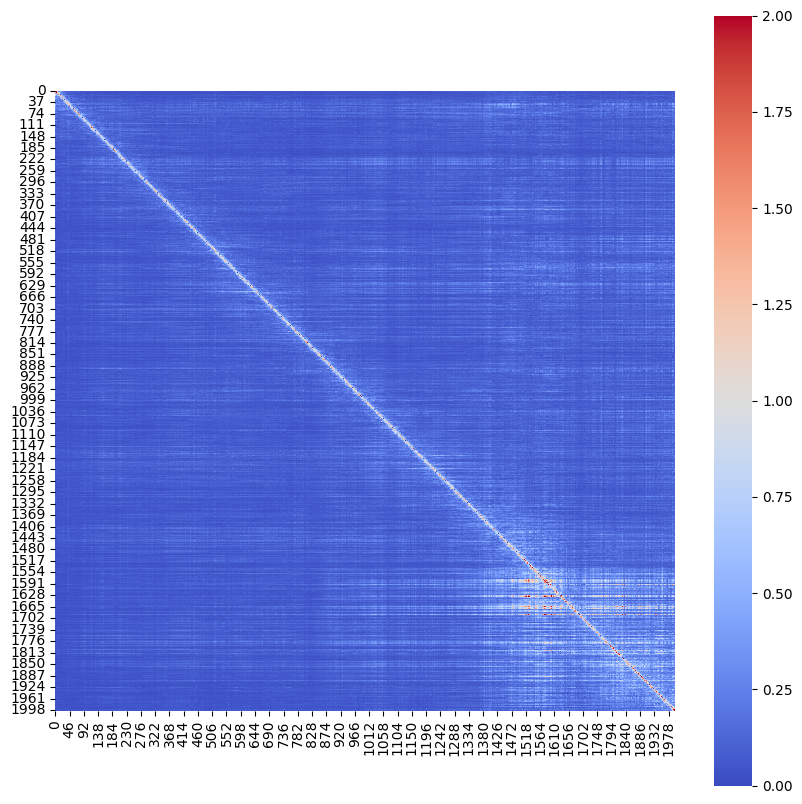

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_map_with_seq(matrix, dna_sequence,  plot_size=10, vmax=5, tick_label_fontsize=8):

    fig, ax = plt.subplots(figsize=(plot_size, plot_size))
    
   
    sns.heatmap(matrix, cmap='coolwarm', vmax=vmax, ax=ax, 
                xticklabels=False, yticklabels=False)  
    ax.set_aspect('equal')

    tick_positions = np.arange(len(dna_sequence)) + 0.5 # Center the ticks

    ax.set_xticks(tick_positions)
    ax.set_yticks(tick_positions)
    ax.set_xticklabels(list(dna_sequence), fontsize=tick_label_fontsize, rotation=0)
    ax.set_yticklabels(list(dna_sequence), fontsize=tick_label_fontsize)

    plt.show()
    
def plot_map(matrix, vmax=None, display_values=False, annot_size=8, fig_size=10):
   
    plt.figure(figsize=(fig_size, fig_size))

    ax = sns.heatmap(matrix, cmap="coolwarm", vmax=vmax, annot=display_values, 
                     fmt=".2f", annot_kws={"size": annot_size})

    ax.set_aspect('equal')

    plt.show()

plot_map(dep_map, vmax=2)

## Attention map

In [ ]:
from model.dataset import GenomeBigWigDataset
from model.utils import load_Data, transform_fn
from model.decorator import NUC_CONFIG
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.amp.autocast_mode import autocast
from tqdm import tqdm

# setting
# Extract attention from last layer
layer_index = -1  # Last layer

# data
faidx = pyfaidx.Fasta(config["fasta_path"])
gene_bed = os.path.join(config["training_data_dir"], config["gene_bed"])
gene_bed = pd.read_csv(gene_bed, sep="\t", header=None, names=["chrom", "start", "end", "id", "type"])
gene_bed = load_Data(gene_bed, faidx, config["TSS_up"], config["TSS_down"]) # TSS up 1500, TSS down 500
faidx.close()

# 随机打乱gene bed
gene_bed = gene_bed.sample(frac=1, random_state=123).reset_index(drop=True)
infer_bed = gene_bed.iloc[:16]

infer_dataset = GenomeBigWigDataset(
    fasta_path=config["fasta_path"],
    bigwig_path_list=[os.path.join(config["training_data_dir"], f) for f in config["bigwig_files"]],
    chrom_regions = infer_bed,
    sequence_length=config["sequence_length"],
    tokenizer=tokenizer,
    transform_fn = transform_fn,
    keep_target_center_fraction=config["keep_target_center_fraction"],
    num_samples=len(infer_bed)
)
infer_dataloader = DataLoader(
    infer_dataset, 
    batch_size=16, 
    shuffle=False, 
    num_workers=config["num_workers"]
)

att_dict = {}
for idx, batch in enumerate(infer_dataloader):
    tokens, bigwig_targets, chrom, start, end = batch["tokens"].to(device), batch["bigwig_targets"].to(device), batch["chrom"], batch["start"], batch["end"]
    with autocast(device_type="cuda", dtype=torch.bfloat16):
        with torch.no_grad():
            outputs = model(tokens, return_dict=True)
        
        attention_maps = outputs.attentions[-1] # List[(batch, heads, seq_len, seq_len)] length:layers
    
    for i in range(attention_maps.shape[0]):
        att_dict[f'{chrom[i]}_{start[i]}_{end[i]}'] = attention_maps[i, :, :, :].cpu().numpy() # (heads, seq_len, seq_len))

In [26]:
att_dict.keys()

dict_keys(['A157_chr06_57751086_57753958', 'A157_chr02_30849584_30852002', 'A157_chr03_51157387_51161460', 'A157_chr06_2006404_2009922', 'A157_chr06_53305169_53310058', 'A157_chr08_40067212_40079752', 'A157_chr09_6683642_6686258', 'A157_chr09_10532090_10534998', 'A157_chr07_49184029_49184483', 'A157_chr08_51763203_51764831', 'A157_chr09_57449204_57457981', 'A157_chr08_49759894_49762247', 'A157_chr04_56480755_56485295', 'A157_chr04_57673172_57679212', 'A157_chr08_43880814_43884852', 'A157_chr05_22806634_22815829'])

In [32]:
# ============================================================
# Pyramid-style Attention Map Plotting (45-degree rotated triangular)
# ============================================================
from matplotlib.colors import TwoSlopeNorm
from matplotlib import pyplot as plt
import numpy as np

# Global settings
LINE_WIDTH = 0.5

def _get_45deg_mesh(mat):
    """Create 45-degree rotated mesh for triangular attention visualization.

    Args:
        mat: Input matrix to create mesh for.

    Returns:
        tuple: (X, Y) mesh coordinates rotated 45 degrees.
    """
    theta = -np.pi / 4
    R = np.array([
        [np.cos(theta), -np.sin(theta)],
        [np.sin(theta), np.cos(theta)]
    ])
    K = len(mat) + 1
    g = np.arange(0, K) - 0.5
    X = np.tile(g[:, None], (1, K))
    Y = np.tile(g[None, :], (K, 1))
    xy = np.array([X.ravel(), Y.ravel()])
    xy_rot = R @ xy
    return xy_rot[0, :].reshape(K, K), xy_rot[1, :].reshape(K, K).T

def plot_attention_panel(mat, filename=None, *, cmap="Blues", vmin=0.0001,
                         vmax=0.005, colorbar=True, dpi=600, figsize=(10, 10),
                         variant_id="", show_titles=True, show_xlabel=True,
                         show_xticks=True, show_yticks=False,
                         positions='TOKEN', token_resolution=128, show=True):
    """Plot triangular attention heatmap with 45-degree rotation (pyramid style).

    Args:
        mat: Attention matrix to plot.
        filename: Output filename. If None and show=True, displays plot.
        cmap: Colormap name. Defaults to "Blues".
        vmin: Minimum value for color scale. Defaults to 0.0001.
        vmax: Maximum value for color scale. Defaults to 0.005.
        colorbar: Whether to show colorbar. Defaults to True.
        dpi: Figure DPI. Defaults to 600.
        figsize: Figure size tuple. Defaults to (10, 10).
        variant_id: Title for the plot. Defaults to "".
        show_titles: Whether to show title. Defaults to True.
        show_xlabel: Whether to show x-axis label. Defaults to True.
        show_xticks: Whether to show x-axis ticks. Defaults to True.
        show_yticks: Whether to show y-axis ticks. Defaults to False.
        positions: 'TOKEN' or 'BP' for position units. Defaults to 'TOKEN'.
        token_resolution: Base pairs per token. Defaults to 128.
        show: Whether to display plot. Defaults to True.

    Returns:
        matplotlib.figure.Figure: The created figure object.
    """
    # Symmetrize matrix
    mat = 0.5 * (mat + mat.T)

    # Mask lower triangle
    mat[np.tril_indices_from(mat, k=-1)] = np.nan
    n = mat.shape[0]
    X, Y = _get_45deg_mesh(mat)

    # Coordinate normalization
    C = 1
    half_pixel_diag = 1 / (2*C)
    pixel_side = 1 / (C * np.sqrt(2))
    X = X * pixel_side + half_pixel_diag
    Y = Y * pixel_side
    Y = -Y  # Flip Y

    # Clean up coordinates
    X = np.nan_to_num(X, nan=0.0, posinf=1.0, neginf=-1.0)
    Y = np.nan_to_num(Y, nan=0.0, posinf=1.0, neginf=-1.0)

    # Set up normalization
    vcenter = (vmin + vmax) / 2
    norm = TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)

    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    im = ax.pcolormesh(X, Y, mat, cmap=cmap, norm=norm, shading="auto")

    # Set axis properties
    ax.set_aspect("equal")

    # Calculate coordinate extents
    finite_mask = np.isfinite(mat)
    if finite_mask.any():
        vertex_mask = np.zeros_like(X, dtype=bool)
        vertex_mask[:-1, :-1] |= finite_mask
        vertex_mask[:-1, 1:] |= finite_mask
        vertex_mask[1:, :-1] |= finite_mask
        vertex_mask[1:, 1:] |= finite_mask

        valid_x = X[vertex_mask]
        valid_y = Y[vertex_mask]
        x_min, x_max = np.nanmin(valid_x), np.nanmax(valid_x)
        y_min, y_max = np.nanmin(valid_y), np.nanmax(valid_y)
    else:
        x_min, x_max = np.nanmin(X), np.nanmax(X)
        y_min, y_max = np.nanmin(Y), np.nanmax(Y)

    triangle_bottom_y = y_min
    triangle_top_y = y_max

    xlim_pad = 0.1
    ylim_pad = 0.1
    y_range = (y_max - y_min) if y_max > y_min else 1.0
    bottom_pad = 0.001 * y_range

    ax.set_xlim(x_min - xlim_pad, x_max + xlim_pad)
    ax.set_ylim(y_min - bottom_pad, y_max + ylim_pad)

    # Add colorbar
    if colorbar:
        pyramid_y_min = y_min
        pyramid_y_max = y_max

        cb = plt.colorbar(im, ax=ax, shrink=1.0, aspect=20, pad=0.1)
        cb.ax.tick_params(width=LINE_WIDTH*0.8, length=3, labelsize=7, direction="in")
        cb.outline.set_linewidth(LINE_WIDTH*0.8)

        ax_pos = ax.get_position()
        axes_y_min_data = y_min - bottom_pad
        axes_y_max_data = y_max + ylim_pad
        axes_height_data = axes_y_max_data - axes_y_min_data

        if axes_height_data > 0:
            pyramid_bottom_frac = (
                (pyramid_y_min - axes_y_min_data) / axes_height_data
            )
            pyramid_top_frac = (
                (pyramid_y_max - axes_y_min_data) / axes_height_data
            )
        else:
            pyramid_bottom_frac = 0
            pyramid_top_frac = 1

        cb_pos = cb.ax.get_position()
        new_y0 = ax_pos.y0 + ax_pos.height * pyramid_bottom_frac
        new_height = ax_pos.height * (pyramid_top_frac - pyramid_bottom_frac)
        cb.ax.set_position(
            [cb_pos.x0, new_y0, cb_pos.width, new_height]
        )

    # Format axes
    use_bp_display = positions.upper() == 'BP'

    ax.tick_params(width=LINE_WIDTH, length=3, labelsize=7)
    for sp in ("top", "right", "left"):
        ax.spines[sp].set_visible(False)
    ax.spines["bottom"].set_linewidth(LINE_WIDTH)
    ax.spines["bottom"].set_position(('data', triangle_bottom_y))
    ax.xaxis.set_ticks_position('bottom')
    ax.xaxis.set_label_position('bottom')

    if show_xticks and mat.size > 0:
        n_tokens = mat.shape[0]
        tick_positions = [0, n_tokens - 1]
        if use_bp_display:
            max_bp = (n_tokens - 1) * token_resolution
            tick_labels = ['0', str(max_bp)]
        else:
            tick_labels = ['0', str(n_tokens - 1)]
        ax.set_xticks(tick_positions)
        ax.set_xticklabels(tick_labels)
    else:
        ax.set_xticks([])

    if not show_yticks:
        ax.set_yticks([])

    if use_bp_display:
        xlabel_text = "Position (base pairs)"
    else:
        xlabel_text = "Token position"
    if show_xlabel:
        ax.set_xlabel(xlabel_text, fontsize=8)

    if show_titles and variant_id:
        ax.set_title(variant_id, fontsize=9, pad=10)

    ax.set_facecolor("white")

    if filename:
        dirname = os.path.dirname(filename)
        if dirname:
            os.makedirs(dirname, exist_ok=True)
        plt.savefig(
            filename, dpi=600, bbox_inches="tight", facecolor='white'
        )
        print(f"✅ Saved attention plot: {filename}")
        if not show:
            plt.close(fig)
    elif show:
        plt.show()
    else:
        plt.close(fig)

    return fig

print("✅ Pyramid-style attention plotting function defined")

✅ Pyramid-style attention plotting function defined


Attention map shape: (200, 200)
Attention value range: [0.000004, 0.241156]


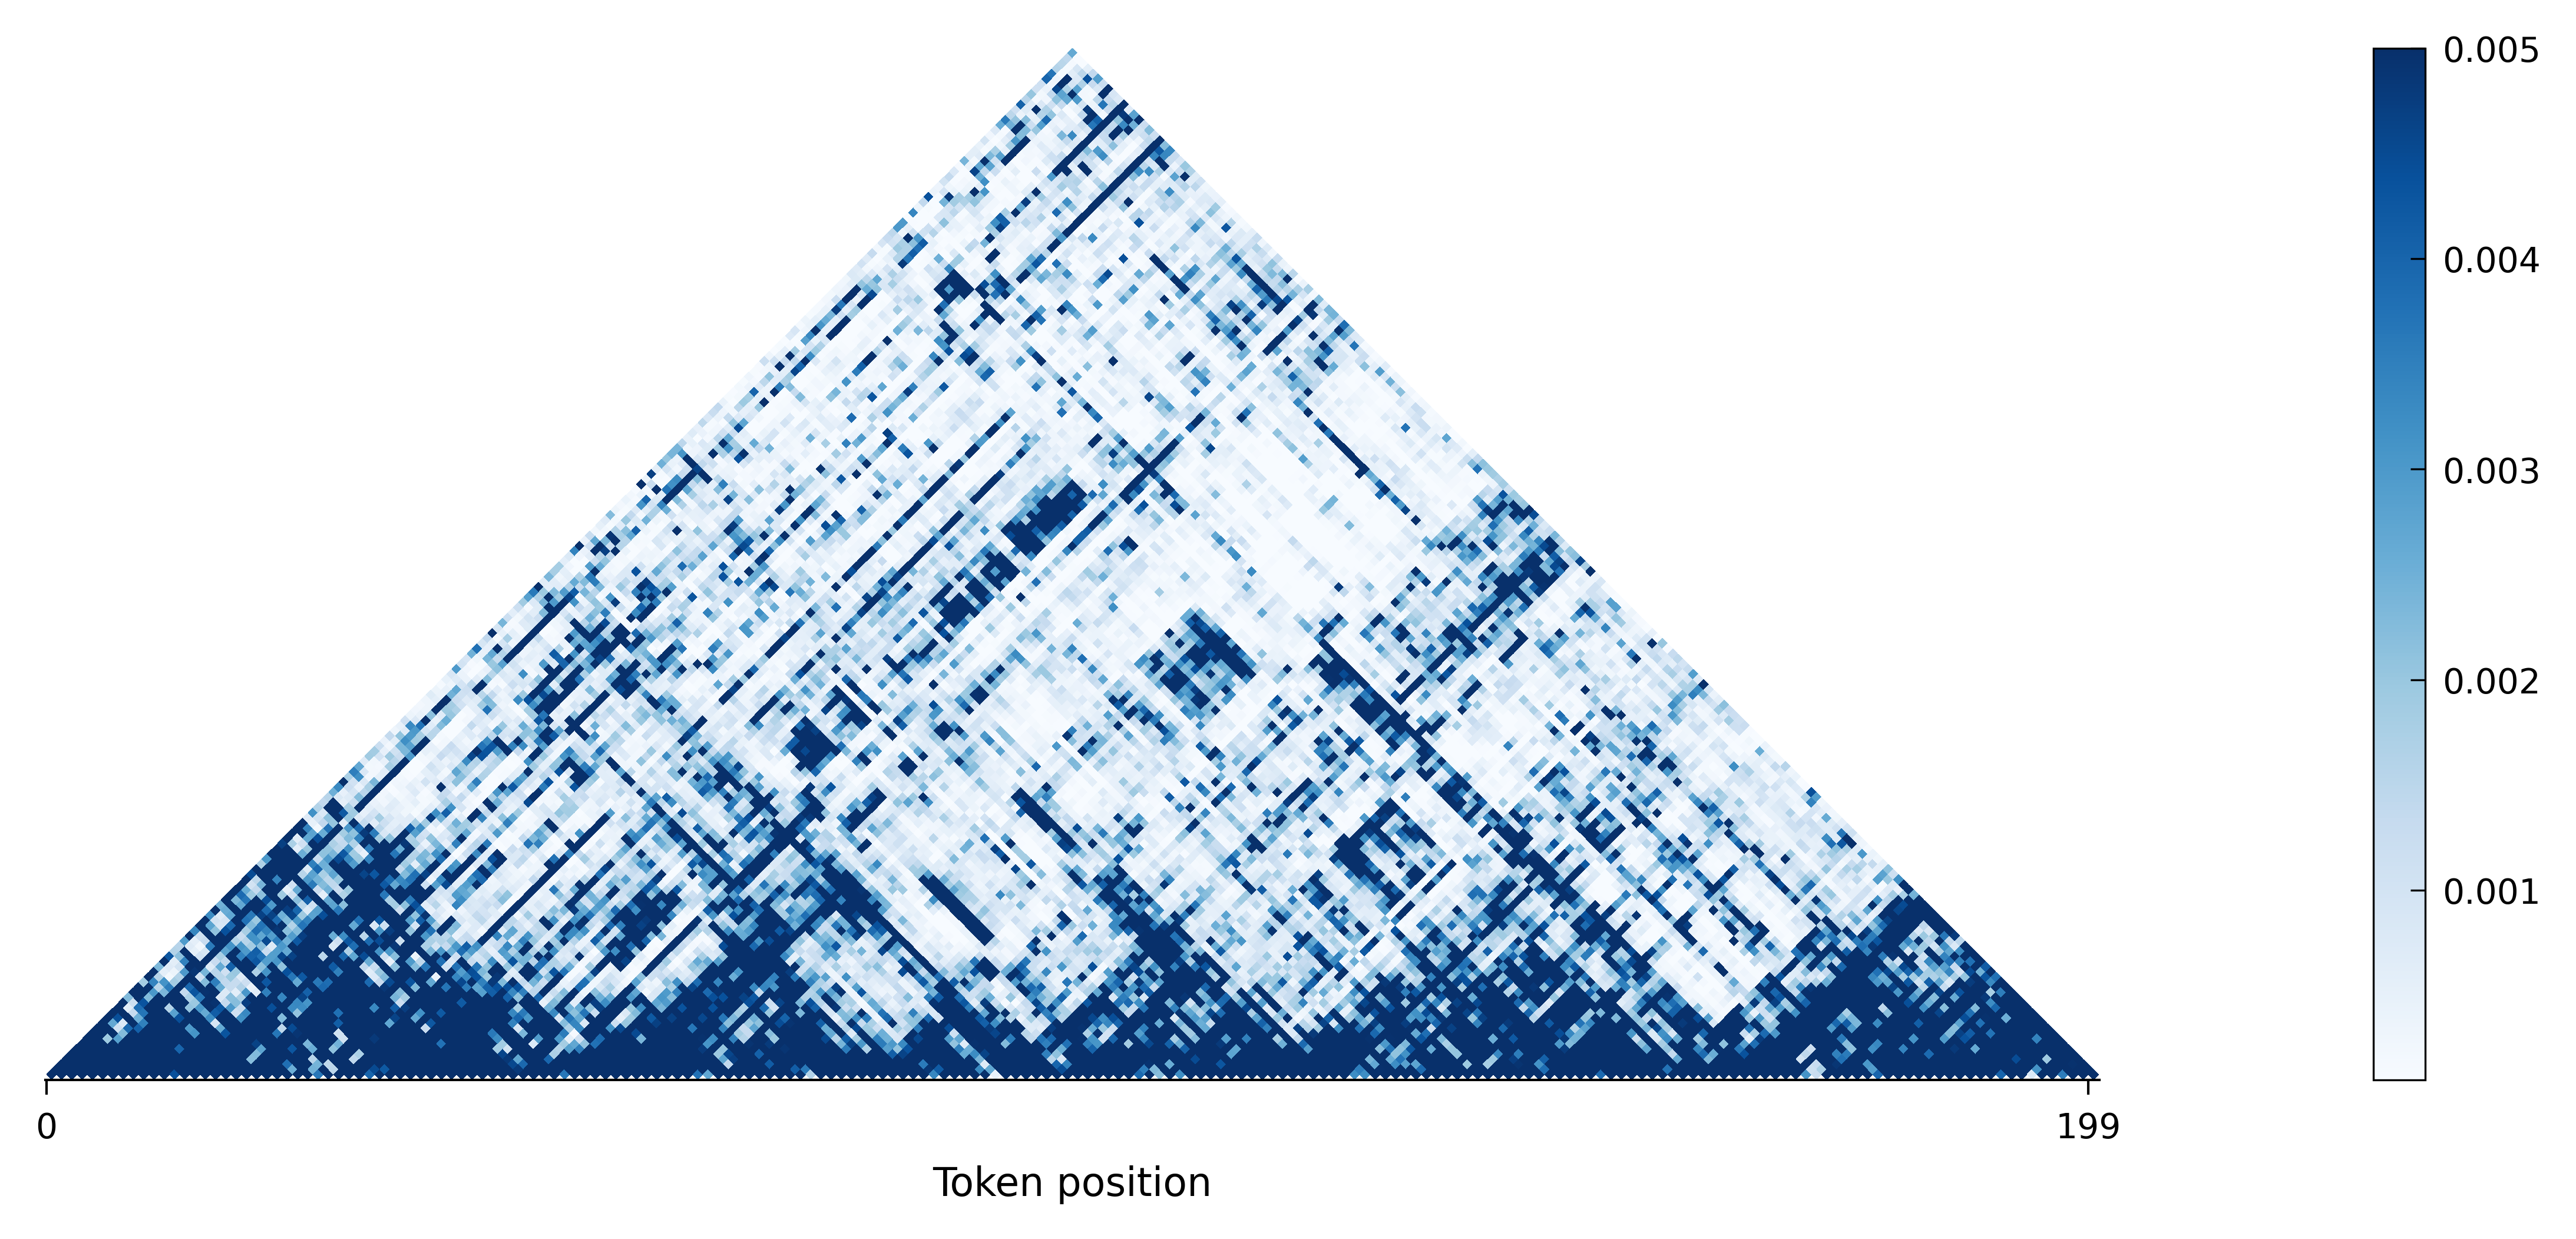

In [33]:
def attention_map(attention_last_layer):
    # Average over heads and symmetrize
    # [seq_len, seq_len]
    attention_mean = attention_last_layer.mean(axis=0)
    attention_mean = 0.5 * (attention_mean + attention_mean.T)  # Symmetrize

    print(f"Attention map shape: {attention_mean.shape}")
    attn_min = attention_mean.min()
    attn_max = attention_mean.max()
    print(f"Attention value range: [{attn_min:.6f}, {attn_max:.6f}]")

    return attention_mean

attention_mean = attention_map(att_dict['A157_chr06_57751086_57753958'])

fig = plot_attention_panel(
    attention_mean,
    cmap="Blues",
    vmin=0.0001,
    vmax=0.005,
    colorbar=True,
    figsize=(10, 10),
    show_xlabel=True,
    show_xticks=True,
    positions='TOKEN',
    show=True,
)

## Predict track

In [ ]:
from model.dataset import GenomeBigWigDataset
from model.utils import load_Data, transform_fn
from model.analysis import visualization_channels_means
from model.decorator import NUC_CONFIG
import torch.nn.functional as F

from torch.utils.data import DataLoader
from torch.amp.autocast_mode import autocast
from tqdm import tqdm

# setting
# Extract attention from last layer
layer_index = -1  # Last layer

# data
faidx = pyfaidx.Fasta(config["fasta_path"])
gene_bed = os.path.join(config["training_data_dir"], config["gene_bed"])
gene_bed = pd.read_csv(gene_bed, sep="\t", header=None, names=["chrom", "start", "end", "id", "type"])
gene_bed = load_Data(gene_bed, faidx, config["TSS_up"], config["TSS_down"]) # TSS up 1500, TSS down 500
faidx.close()

# 随机打乱gene bed
gene_bed = gene_bed.sample(frac=1, random_state=123).reset_index(drop=True)
infer_bed = gene_bed.iloc[:16]

infer_dataset = GenomeBigWigDataset(
    fasta_path=config["fasta_path"],
    bigwig_path_list=[os.path.join(config["training_data_dir"], f) for f in config["bigwig_files"]],
    chrom_regions = infer_bed,
    sequence_length=config["sequence_length"],
    tokenizer=tokenizer,
    transform_fn = transform_fn,
    keep_target_center_fraction=config["keep_target_center_fraction"],
    num_samples=len(infer_bed)
)
infer_dataloader = DataLoader(
    infer_dataset, 
    batch_size=16, 
    shuffle=False, 
    num_workers=config["num_workers"]
)

att_dict = {}
for idx, batch in enumerate(infer_dataloader):
    tokens, bigwig_targets, chrom, start, end = batch["tokens"].to(device), batch["bigwig_targets"].to(device), batch["chrom"], batch["start"], batch["end"]
    with autocast(device_type="cuda", dtype=torch.bfloat16):
        with torch.no_grad():
            outputs = model(tokens, return_dict=True)
        
        attention_maps = outputs.attentions[-1] # List[(batch, heads, seq_len, seq_len)] length:layers
    
    for i in range(attention_maps.shape[0]):
        att_dict[f'{chrom[i]}_{start[i]}_{end[i]}'] = attention_maps[i, :, :, :].cpu().numpy() # (heads, seq_len, seq_len))

## Saliency Map

In [17]:
from model.head import HFModelWithHead_Saliency, SaliencyComputer
from model.utils import (
    load_config, init_config, 
    init_model, load_ckpt_with_compile, 
    load_Data, transform_fn
)
from model.dataset import GenomeBigWigDataset
from model.analysis import visualization_channels_means
from model.decorator import NUC_CONFIG
from model.metrics import InferMetrics

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp.autocast_mode import autocast

from tqdm import tqdm
from typing import Dict, Tuple
import pyfaidx
import os
import pandas as pd
import numpy as np
import toml
from tqdm import tqdm

config = load_config("config/fineturn_my.toml")
config = init_config(config)
model, tokenizer = init_model(config, HFModelWithHead_Saliency)

# load ckpt
device = "cuda:1"
ckpt_path = "/vepfs-C/vepfs_public/daijc/lncRNA/checkpoints/NTv3-pre-100M_fineturn_12.8k_epcho41-val_pcc0.55.ckpt"
model = load_ckpt_with_compile(model, ckpt_path, device, compile=True, strict=False)
model = model.to(device)
model.eval()

# init saliency computer
saliency_computer = SaliencyComputer(
    model=model, # HFModelWithHead_Saliency
    tokenizer=tokenizer,
    sequence_length=config["sequence_length"],
    track_indices=None,
    region=None,
    device=device
)

# data
faidx = pyfaidx.Fasta(config["fasta_path"])
gene_bed = os.path.join(config["training_data_dir"], config["gene_bed"])
gene_bed = pd.read_csv(gene_bed, sep="\t", header=None, names=["chrom", "start", "end", "id", "type"])
gene_bed = load_Data(gene_bed, faidx, config["TSS_up"], config["TSS_down"]) # TSS up 1500, TSS down 500
faidx.close()

# 随机打乱gene bed
gene_bed = gene_bed.sample(frac=1, random_state=123).reset_index(drop=True)
infer_bed = gene_bed.iloc[:16]

Seed set to 42


In [18]:
infer_bed

,chrom,start,end,id,type,region_start,region_end
0,A157_chr02,32777140,32803073,TCONS_00004530,mRNA,32764340,32789940
1,A157_chr06,36302268,36308052,TCONS_00010911,mRNA,36289468,36315068
2,A157_chr12,6568455,6583890,TCONS_00020352,mRNA,6555655,6581255
3,A157_chr01,67633541,67640619,TCONS_00001962,mRNA,67620741,67646341
4,A157_chr06,35698550,35701736,TCONS_00010900,mRNA,35685750,35711350
5,A157_chr05,55455499,55461521,TCONS_00010567,mRNA,55442699,55468299
6,A157_chr01,82060692,82062887,TCONS_00001144,mRNA,82047892,82073492
7,A157_chr05,10896058,10900215,TCONS_00009507,mRNA,10883258,10908858
8,A157_chr01,68522232,68527034,TCONS_00000644,mRNA,68509432,68535032
9,A157_chr02,34422393,34424008,TCONS_00003579,mRNA,34409593,34435193


In [20]:
faidx = pyfaidx.Fasta(config["fasta_path"])
seq = faidx['A157_chr02'][32764340:32789940].seq
grads, one_hot_nps = saliency_computer.compute_saliency(seq)

## modiscolite result

In [1]:
import h5py

grp = h5py.File("/vepfs-C/vepfs_public/daijc/lncRNA/results/grads/modisco_all.h5", "r")

In [ ]:
all_index = []
for contribution_dir in ['pos', 'neg']:
    patterns_category = f'{contribution_dir}_patterns'
    if patterns_category not in grp:
		continue

	for (pattern_name, datasets) in grp[patterns_category].items():
        all_index.append(
            datasets['seqlets']['example_idx'][:]
        )


<HDF5 dataset "end": shape (41,), type "<i8">